In [2]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [3]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/fullRuns') # path to parent of output_root in set_parameters
out_dir = Path('outputs/study4') # path dir to save outputs in

study_prefix = 'study4' # start of dir name of output_root in set_parameters
studies = [''] # individual study identifier (end of dir name of output_root in set_parameters)

In [47]:
get_runtimes(root_dir, study_prefix, studies).to_csv(out_dir / 'runtimes.csv', index=False)

info = get_info_df('CMC')

df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, ['study4-10'])

df_bone.to_csv(out_dir / 'df_bone10.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart10.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual10.csv', index=False)

In [4]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone10.csv')
df_cart = pd.read_csv(out_dir / 'df_cart10.csv')
df_qual = pd.read_csv(out_dir / 'df_qual10.csv')


df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [49]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'orig'
iteration_bone = 'orig'
loc = 'i'

qual_metric = '99.9%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    #f'{qual_part}_min_angle_{qual_metric}',
    #f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        #f'{qual_part}_min_angle_{qual_metric}',
        #f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        #f'{qual_part}_aspect_ratio_{qual_metric}',
        #f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

36


Highest element count:
	14726R - 632479


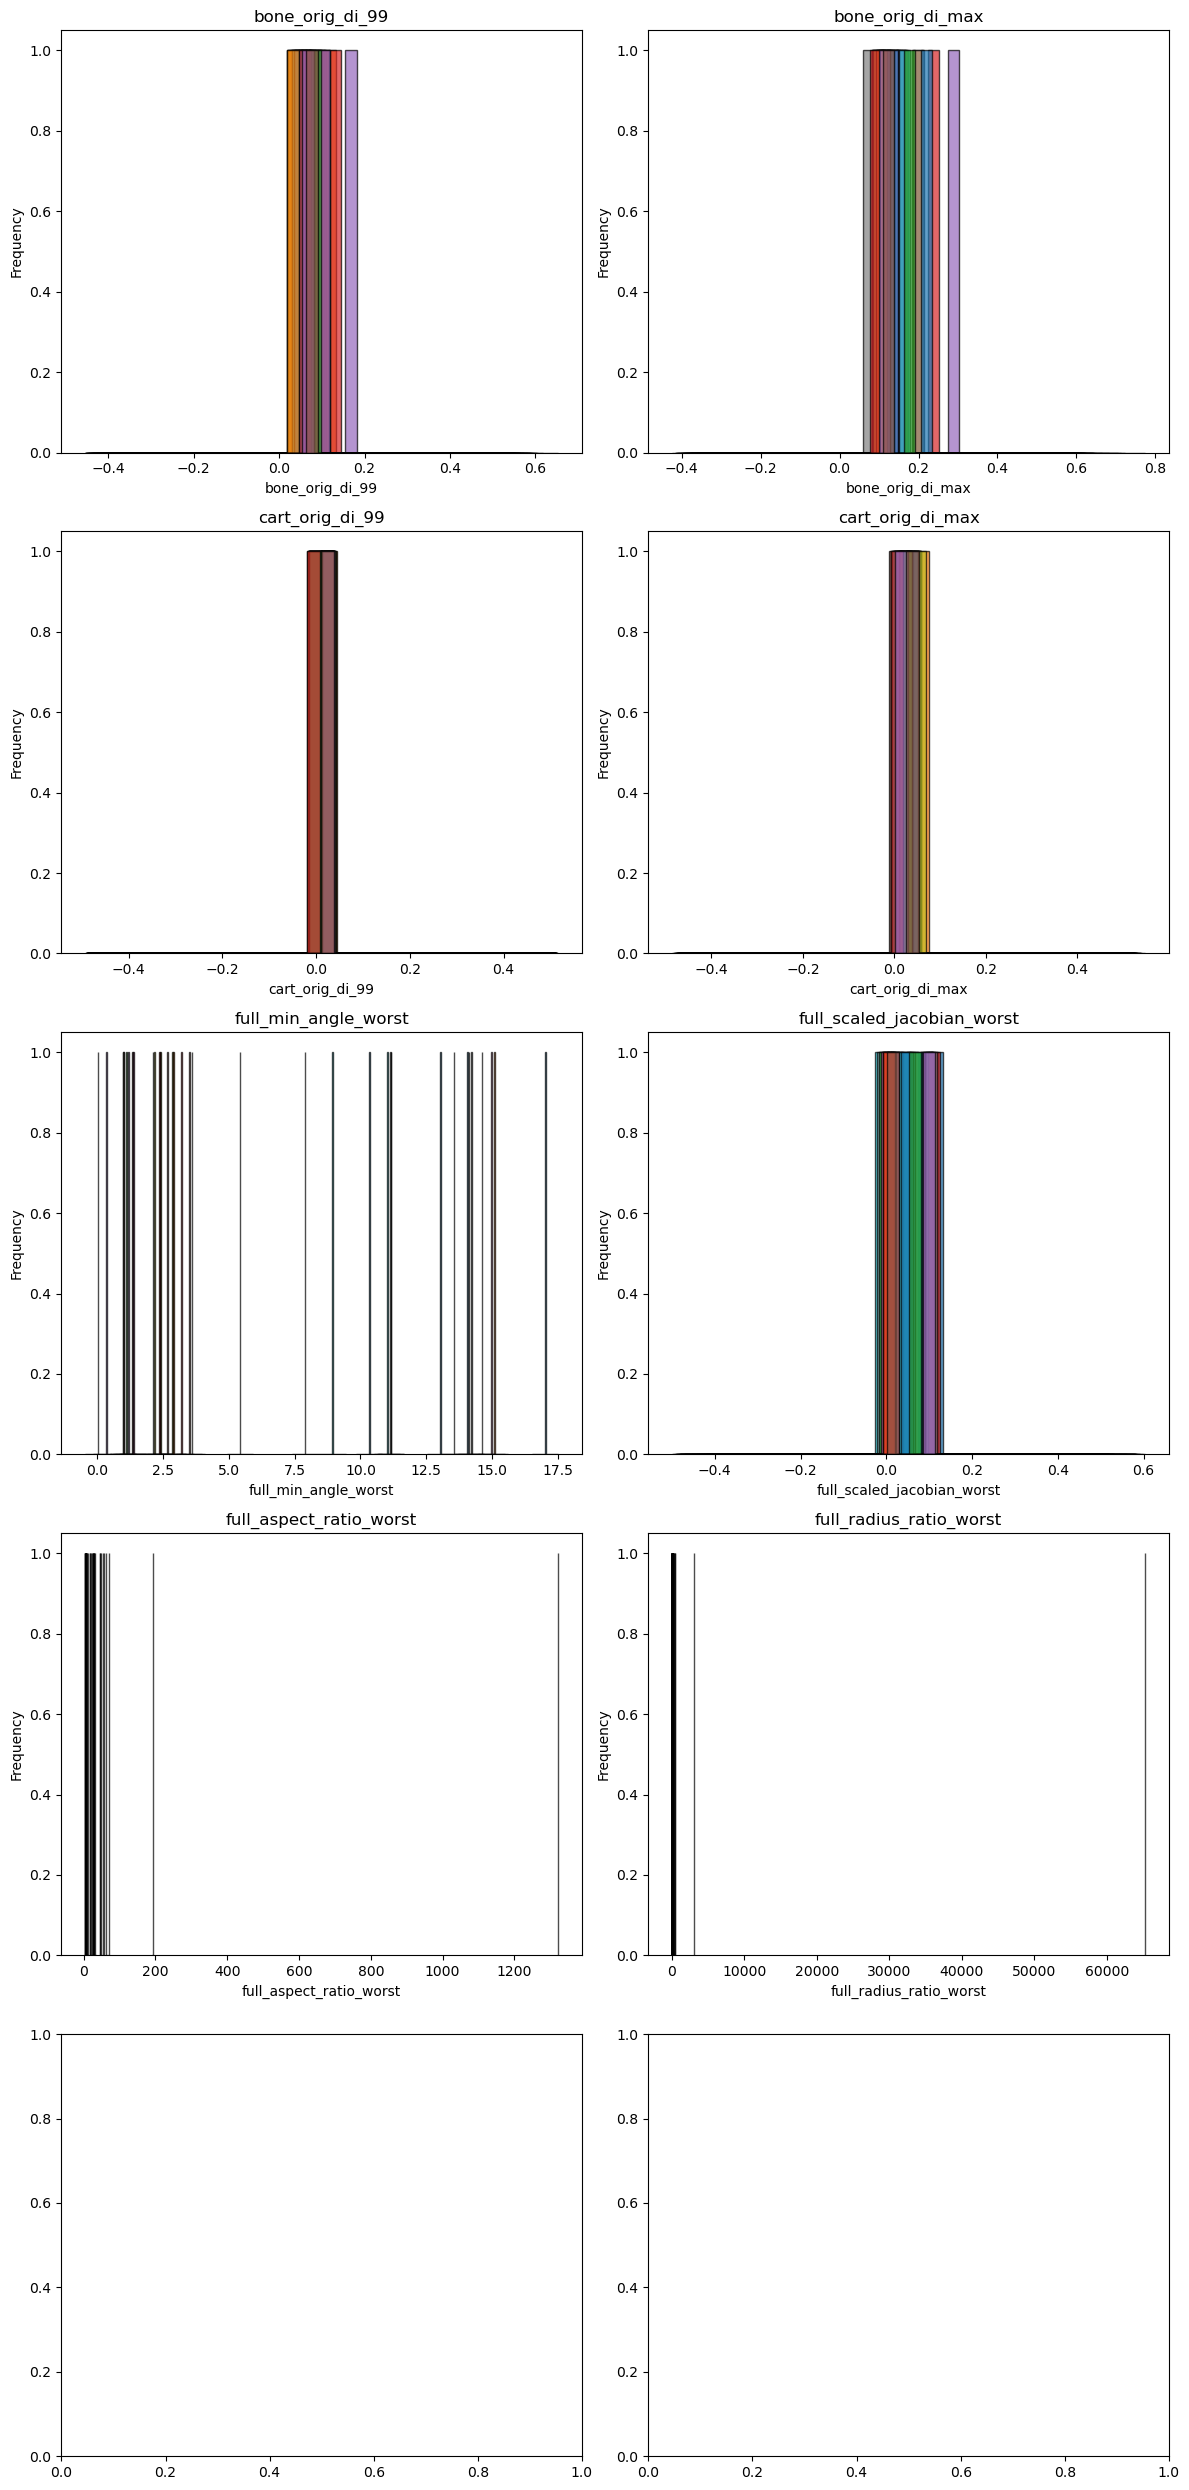

In [50]:
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = len(df)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

### Why are the top 14 all good , then sudden drop off for the rest???
### Why is it 14 again but a different 14???
- 14874R was good last time ?????????
- 15294R was one of the worst ?????????

In [ ]:
# rerun with identical params...
qual[qual['bone']==bone].sort_values('full_radius_ratio_worst').reset_index(drop=True)

,sub,bone,run_id,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,full_n_cells
0,14548R,tpm,0-10,17.003427,0.103752,4.352316,4.326900,177516
1,15006R,tpm,0-10,14.033385,0.078933,5.576907,4.929113,315854
2,50017L,tpm,0-10,14.100517,0.097905,4.639593,5.073871,272410
3,15283R,tpm,0-10,15.078432,0.085011,4.689136,5.189110,504130
4,15294R,tpm,0-10,13.533900,0.075811,5.464435,5.199839,380687
5,50037L,tpm,0-10,14.599818,0.081583,4.928017,5.266721,208141
6,14827L,tpm,0-10,14.184838,0.082161,5.673964,5.347585,256296
7,50000R,tpm,0-10,14.966762,0.091742,5.249706,5.367590,230803
8,50049R,tpm,0-10,11.146696,0.085978,5.618281,5.453981,258226
9,50007L,tpm,0-10,8.932777,0.083181,6.353896,5.499400,180384


In [63]:
qual.sort_values('full_radius_ratio_worst').reset_index(drop=True)

,sub,bone,run_id,full_min_angle_worst,full_scaled_jacobian_worst,full_aspect_ratio_worst,full_radius_ratio_worst,full_n_cells
0,14548R,tpm,0-0,17.003427,0.103752,4.352316,4.326900,177516
1,15006R,tpm,0-0,15.220278,0.107411,4.965209,4.680918,315718
2,50017L,tpm,0-0,14.100517,0.097905,4.639593,5.073871,272410
3,14827L,tpm,0-0,16.479411,0.097955,5.211019,5.149943,256298
4,14874R,tpm,0-0,13.713532,0.086589,5.501786,5.156031,473821
5,50037L,tpm,0-0,14.599818,0.081583,4.928017,5.266721,208141
6,50000R,tpm,0-0,14.966762,0.091742,5.249706,5.367590,230803
7,50049R,tpm,0-0,11.146696,0.085978,5.618281,5.453981,258226
8,50007L,tpm,0-0,8.932777,0.083181,6.353896,5.499400,180384
9,50027L,tpm,0-0,11.015094,0.058375,7.124288,5.913400,261030


In [ ]:
['14727R', '15294R', '50018L', '50001R', '14613R', '50016L'] # optimise3D/study5 subjects

In [55]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/ParamOptimisation/fullRuns/study4/meshes/14874R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu'
mesh = pv.read(path)
mesh.plot()



Widget(value='<iframe src="http://localhost:59090/index.html?ui=P_0x33f3974a0_0&reconnect=auto" class="pyvista…

In [56]:
q = check_mesh_quality(mesh.extract_cells_by_type(10), 'tet')
mesh_quality_summary(q, 'tet')

min_angle 6/473867 cells outside of acceptable range (10, 70.53)
max_angle 3/473867 cells outside of acceptable range (70.53, 170)
radius_ratio 175/473867 cells outside of acceptable range (1.0, 3.0)
shape 52/473867 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 594/473867 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 37/473867 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 589/473867 cells outside of acceptable range (1.0, 2.0)
condition 117/473867 cells outside of acceptable range (1.0, 3.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,52.527329,69.603219,0.055953,"(10, 70.53)",99.998734,6,"(37.7, 69.6)"
max_angle,94.464319,71.142587,179.907213,"(70.53, 170)",99.999367,3,"(71.14, 116.95)"
radius_ratio,1.300583,1.000449,65283.877837,"(1.0, 3.0)",99.963070,175,"(1.0, 1.42)"
shape,0.894466,0.999632,0.007806,"(0.4, 1.0)",99.989026,52,"(0.76, 1.0)"
aspect_ratio,1.345994,1.009713,1321.771752,"(1.0, 3.0)",99.874648,594,"(1.01, 1.7)"
scaled_jacobian,0.725731,0.990968,0.000378,"(0.2, 1.0)",99.992192,37,"(0.49, 0.99)"
aspect_frobenius,1.127571,1.000368,128.107574,"(1.0, 2.0)",99.875704,589,"(1.0, 1.32)"
condition,1.137803,1.000369,1133.303001,"(1.0, 3.0)",99.975310,117,"(1.0, 1.35)"


## Run 14874 with lloyd.freeze_bound = [0.002, 0.001, 0.0005], 600s

In [1]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/study4/14874R/params/full_params.json

SUBJECT: 14874R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 3.767s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 7.613s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 321.685s - ok
			RUN ID: -0-0-1
			Runtime: 551.448s - ok
			RUN ID: -0-0-2
			Runtime: 641.705s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [5]:
run1 = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/fullRuns/outputs/study4/14874R/meshes/14874R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu')
run2 = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/fullRuns/outputs/study4/14874R/meshes/14874R/tpm-mc1/3Dmesh/mesh-0-0-1.vtu')
run3 = pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/fullRuns/outputs/study4/14874R/meshes/14874R/tpm-mc1/3Dmesh/mesh-0-0-2.vtu')



In [8]:
q = check_mesh_quality(run3.extract_cells_by_type(10), 'tet')
mesh_quality_summary(q, 'tet')

radius_ratio 50/473802 cells outside of acceptable range (1.0, 3.0)
shape 9/473802 cells outside of acceptable range (0.4, 1.0)
aspect_ratio 442/473802 cells outside of acceptable range (1.0, 3.0)
scaled_jacobian 24/473802 cells outside of acceptable range (0.2, 1.0)
aspect_frobenius 433/473802 cells outside of acceptable range (1.0, 2.0)
condition 17/473802 cells outside of acceptable range (1.0, 3.0)


,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,52.474039,69.751686,16.091616,"(10, 70.53)",100.000000,0,"(37.68, 69.75)"
max_angle,94.409191,71.246160,155.156568,"(70.53, 170)",100.000000,0,"(71.25, 116.89)"
radius_ratio,1.162097,1.000309,4.359574,"(1.0, 3.0)",99.989447,50,"(1.0, 1.42)"
shape,0.894320,0.999747,0.327083,"(0.4, 1.0)",99.998100,9,"(0.76, 1.0)"
aspect_ratio,1.342203,1.008470,4.972172,"(1.0, 3.0)",99.906712,442,"(1.01, 1.69)"
scaled_jacobian,0.725221,0.993832,0.096399,"(0.2, 1.0)",99.994935,24,"(0.49, 0.99)"
aspect_frobenius,1.127309,1.000253,3.057324,"(1.0, 2.0)",99.908612,433,"(1.0, 1.32)"
condition,1.135214,1.000252,4.034370,"(1.0, 3.0)",99.996412,17,"(1.0, 1.35)"
